In [22]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [9]:
import cv2

print(cv2.__version__)
print(cv2.__file__)
print(hasattr(cv2, "CascadeClassifier"))

4.10.0
c:\Users\ASUS\anaconda3\envs\KNCVU\Lib\site-packages\cv2\__init__.py
True


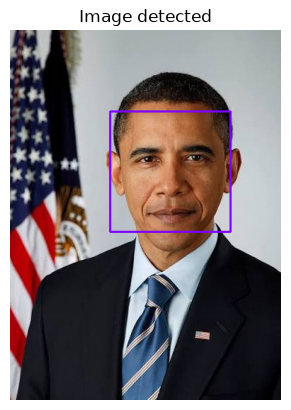

In [10]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Load our image then convert it to grayscale
image = cv2.imread('Obama.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Our classifier returns the ROI of the detected face as a tuple
# It stores the top left coordinate and the bottom right coordiantes
faces = face_cascade.detectMultiScale(gray, scaleFactor = 1.3, minNeighbors = 5)

# When no faces detected, face_classifier returns and empty tuple
if faces is None:
    print("No faces found")

# We iterate through our faces array and draw a rectangle
# over each face in faces
for (x,y,w,h) in faces:
    cv2.rectangle(image, (x,y), (x+w,y+h), (127,0,255), 2)

plt.imshow(image)
plt.title("Image detected")
plt.axis('off')
plt.show()

## OpenCV version for CaseCade 4.10.0

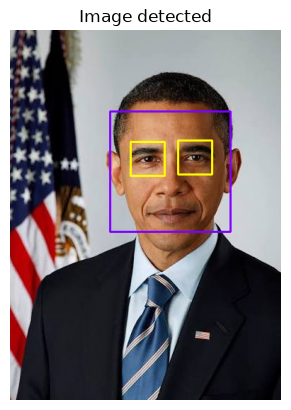

In [23]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_eye.xml")
 
img = cv2.imread('Obama.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(gray, 1.3, 5)

# When no faces detected, face_classifier returns and empty tuple
if faces is None:
    print("No Face Found")

for (x,y,w,h) in faces:
    cv2.rectangle(img,(x,y),(x+w,y+h),(127,0,255),2)
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = img[y:y+h, x:x+w]
    # eyes = eys_cascade.detectMultiScale(roi_gray, 1.2, 3)
    eyes = eye_cascade.detectMultiScale(
            roi_gray,
            scaleFactor=1.01,
            minNeighbors=15)

    for (ex,ey,ew,eh) in eyes:
        cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(255,255,0),2)

plt.imshow(img)
plt.title("Image detected")
plt.axis('off')
plt.show()

In [25]:
import cv2
import os

def capture_photo(filename='photo.jpg', camera_index=0):
    """
    Opens the webcam, shows a live preview, and saves a photo
    when you press SPACE. Press ESC to quit without saving.
    """
    cap = cv2.VideoCapture(camera_index, cv2.CAP_DSHOW)  # CAP_DSHOW avoids slow startup on Windows

    if not cap.isOpened():
        raise RuntimeError("Could not open webcam. Check that it's connected and not in use by another app.")

    print("Press SPACE to capture the photo, ESC to cancel.")

    captured = False
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Failed to grab frame from webcam.")
            break

        cv2.imshow('Webcam - Press SPACE to capture, ESC to cancel', frame)
        key = cv2.waitKey(1) & 0xFF

        if key == 27:  # ESC
            print("Cancelled.")
            break
        elif key == 32:  # SPACE
            cv2.imwrite(filename, frame)
            print(f"Photo saved to {filename}")
            captured = True
            break

    cap.release()
    cv2.destroyAllWindows()
    return filename if captured else None


def detect_face_and_eyes(filename='photo.jpg'):
    """
    Runs Haar cascade face and eye detection on the given image
    and displays the result in a window.
    """
    if not os.path.exists(filename):
        raise FileNotFoundError(f"{filename} not found. Capture a photo first.")

    # cv2.data.haarcascades points to the cascades bundled with opencv-python,
    # so you don't need to manage a local Haarcascades folder.
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

    img = cv2.imread(filename)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)

    if len(faces) == 0:
        print("No Face Found")
    else:
        print(f"Found {len(faces)} face(s)")

    for (x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x + w, y + h), (127, 0, 255), 2)
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]

        eyes = eye_cascade.detectMultiScale(
            roi_gray,
            scaleFactor=1.05,
            minNeighbors=10,
            minSize=(20, 20)
        )

        print(f"  -> Found {len(eyes)} eye(s) in this face")

        for (ex, ey, ew, eh) in eyes:
            cv2.rectangle(roi_color, (ex, ey), (ex + ew, ey + eh), (255, 255, 0), 2)

    cv2.imshow('Face & Eye Detection - Press any key to close', img)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

    # Optionally save the annotated result
    cv2.imwrite('photo_detected.jpg', img)
    print("Annotated image saved to photo_detected.jpg")


if __name__ == '__main__':
    photo_path = capture_photo('photo.jpg')
    if photo_path:
        detect_face_and_eyes(photo_path)

Press SPACE to capture the photo, ESC to cancel.
Photo saved to photo.jpg
Found 1 face(s)
  -> Found 2 eye(s) in this face
Annotated image saved to photo_detected.jpg
